In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import glob

# 设置随机种子，保证结果可复现
tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow Version: {tf.__version__}")

TensorFlow Version: 2.20.0


In [12]:
# --- 配置参数 ---
DATA_DIR = "./TraningData"  # 数据存放目录
MODELS_DIR = "./Models"     # 模型保存目录
CLASS_NAMES = ["0", "1", "2", "3", "4", "5", "6", "7"] # 对应文件夹名：左右上下IDEL
NUM_CLASSES = len(CLASS_NAMES)

# 你的数据采集参数（务必与嵌入式端保持一致）
TIME_STEPS = 128  # 采样点数
CHANNELS = 3      # X, Y, Z 轴

# 确保模型目录存在
if not os.path.exists(MODELS_DIR):
    os.makedirs(MODELS_DIR)

In [13]:
def load_data():
    X = []
    y = []

    print("开始加载数据...")

    for label_idx, class_name in enumerate(CLASS_NAMES):
        folder_path = os.path.join(DATA_DIR, class_name)
        csv_files = glob.glob(os.path.join(folder_path, "*.csv"))

        print(f"正在处理类别 '{class_name}' (Label: {label_idx}), 共找到 {len(csv_files)} 个文件")

        for file_path in csv_files:
            try:
                # 读取CSV，假设没有表头，只有数据
                df = pd.read_csv(file_path, header=None)
                data = df.values # 转为 numpy 数组

                # --- 数据完整性检查 ---
                # 如果采集的数据少于 128行，进行填充；多于128行，进行截断
                if data.shape[0] < TIME_STEPS:
                    # 补零 (Zero Padding)
                    padding = np.zeros((TIME_STEPS - data.shape[0], CHANNELS))
                    data = np.vstack((data, padding))
                elif data.shape[0] > TIME_STEPS:
                    # 截断 (Truncating)
                    data = data[:TIME_STEPS, :]

                X.append(data)
                y.append(label_idx)

            except Exception as e:
                print(f"读取文件错误: {file_path}, {e}")

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.int32)

    print(f"\n加载完成!")
    print(f"输入数据形状 X: {X.shape}") # 应该是 (样本总数, 128, 3)
    print(f"标签数据形状 y: {y.shape}")

    return X, y

# 执行加载
X_all, y_all = load_data()

开始加载数据...
正在处理类别 '0' (Label: 0), 共找到 67 个文件
正在处理类别 '1' (Label: 1), 共找到 56 个文件
正在处理类别 '2' (Label: 2), 共找到 53 个文件
正在处理类别 '3' (Label: 3), 共找到 56 个文件
正在处理类别 '4' (Label: 4), 共找到 54 个文件
正在处理类别 '5' (Label: 5), 共找到 64 个文件
正在处理类别 '6' (Label: 6), 共找到 54 个文件
正在处理类别 '7' (Label: 7), 共找到 52 个文件

加载完成!
输入数据形状 X: (456, 128, 3)
标签数据形状 y: (456,)


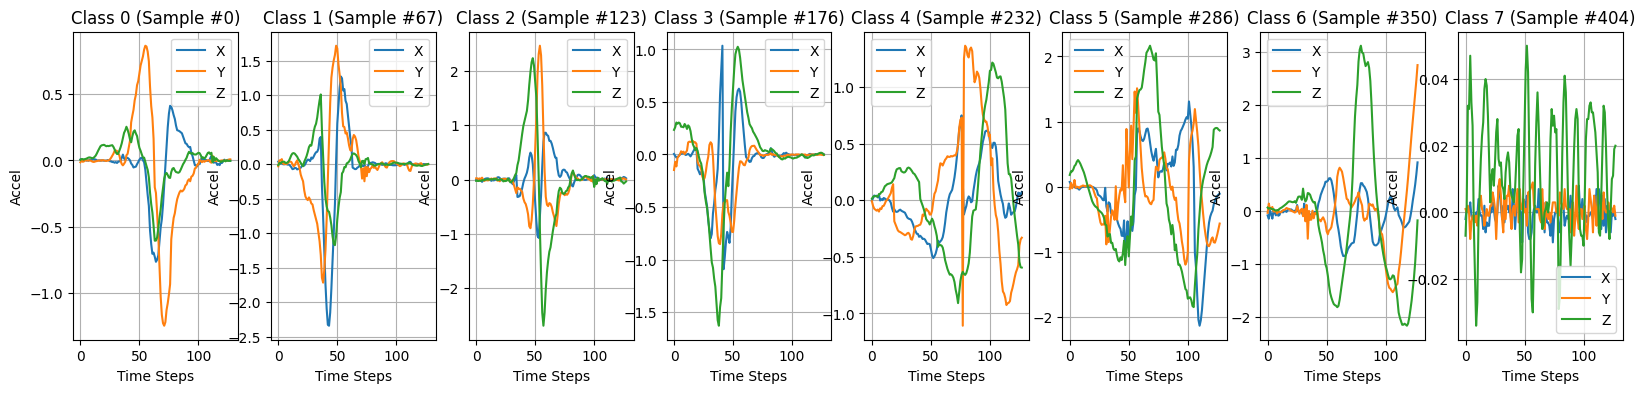

In [14]:
def plot_samples(X, y):
    fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(20, 4))

    for i in range(NUM_CLASSES):
        # 找到该类别的第一个样本的索引
        idx = np.where(y == i)[0][0]
        sample = X[idx]

        axes[i].plot(sample)
        axes[i].set_title(f"Class {CLASS_NAMES[i]} (Sample #{idx})")
        axes[i].set_xlabel("Time Steps")
        axes[i].set_ylabel("Accel")
        axes[i].legend(['X', 'Y', 'Z'])
        axes[i].grid(True)

    plt.show()

plot_samples(X_all, y_all)

In [15]:
# 80% 训练，20% 测试
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

print(f"训练集数量: {len(X_train)}")
print(f"测试集数量: {len(X_test)}")

训练集数量: 364
测试集数量: 92


In [16]:
def create_model():
    model = models.Sequential([
        # 输入层
        layers.InputLayer(input_shape=(TIME_STEPS, CHANNELS)),

        # 第一层卷积
        layers.Conv1D(filters=16, kernel_size=5, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        # 第二层卷积
        layers.Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        # 第三层卷积
        layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(pool_size=2),

        # Dropout 防止过拟合
        layers.Dropout(0.2),

        # 全局平均池化 (替代 Flatten，极大减小参数)
        layers.GlobalAveragePooling1D(),

        # 输出层 (Softmax)
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

model = create_model()
model.summary()

d:\Anaconda\anaconda\envs\tf_env\lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 128, 16)        │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128, 16)        │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 64, 16)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 64, 32)         │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 32, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 32, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,000 (35.16 KB)

 Trainable params: 8,776 (34.28 KB)

 Non-trainable params: 224 (896.00 B)

In [17]:
# 编译模型
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# 开始训练
EPOCHS = 60
BATCH_SIZE = 16

history = model.fit(
    X_train, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/60


23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4255 - loss: 1.6046 - val_accuracy: 0.4457 - val_loss: 1.9993
Epoch 2/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8979 - loss: 0.8377 - val_accuracy: 0.2283 - val_loss: 1.9536
Epoch 3/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9601 - loss: 0.5435 - val_accuracy: 0.1739 - val_loss: 1.9081
Epoch 4/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9826 - loss: 0.3713 - val_accuracy: 0.2500 - val_loss: 1.8541
Epoch 5/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9832 - loss: 0.2677 - val_accuracy: 0.2500 - val_loss: 1.7884
Epoch 6/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9891 - loss: 0.2033 - val_accuracy: 0.2500 - val_loss: 1.7210
Epoch 7/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9959 - loss: 0.1638 - val_accuracy: 0.2283 - val_loss: 1.6681
Epoch 8/60
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9931 - loss: 0.1328 - val_accuracy: 0.2717 - val_loss: 1.5819
Ep

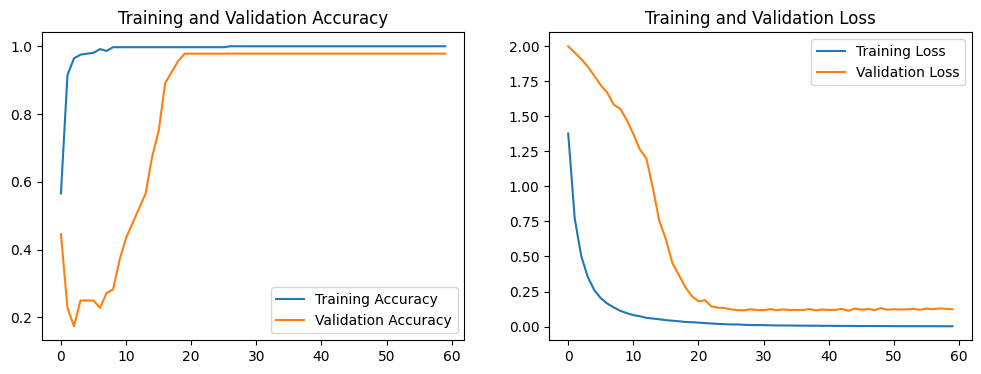

In [18]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [19]:
# 1. 保存 Keras 原始模型
keras_model_path = os.path.join(MODELS_DIR, "gesture_model.h5")
model.save(keras_model_path)
print(f"Keras模型已保存: {keras_model_path}")

# 2. 准备量化数据集 (Representative Dataset)
# TFLite 转换器需要这组数据来确定量化范围(Min/Max)
def representative_data_gen():
    for i in range(len(X_train)):
        input_value = X_train[i].astype(np.float32)
        # 增加 batch 维度: (128, 3) -> (1, 128, 3)
        input_value = np.expand_dims(input_value, axis=0)
        yield [input_value]

# 3. 配置转换器
converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen

# 强制全整数量化 (输入输出也是 int8，这对 ESP-NN 加速很重要)
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

# 4. 执行转换
tflite_model_quant = converter.convert()

# 5. 保存 .tflite 文件
tflite_model_path = os.path.join(MODELS_DIR, "gesture_model_quant.tflite")
with open(tflite_model_path, 'wb') as f:
    f.write(tflite_model_quant)

print(f"量化模型已保存: {tflite_model_path}")
print(f"模型大小: {len(tflite_model_quant) / 1024:.2f} KB")

Keras模型已保存: ./Models\gesture_model.h5
INFO:tensorflow:Assets written to: C:\Users\11130\AppData\Local\Temp\tmpv_bgs6lz\assets


INFO:tensorflow:Assets written to: C:\Users\11130\AppData\Local\Temp\tmpv_bgs6lz\assets


Saved artifact at 'C:\Users\11130\AppData\Local\Temp\tmpv_bgs6lz'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 3), dtype=tf.float32, name='keras_tensor_13')
Output Type:
  TensorSpec(shape=(None, 8), dtype=tf.float32, name=None)
Captures:
  2961536925536: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2961536934832: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2961536950688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2961536951216: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2961536937824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2961536950336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2961536953504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2961536953152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2961536968128: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2961536968656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2961536

d:\Anaconda\anaconda\envs\tf_env\lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


量化模型已保存: ./Models\gesture_model_quant.tflite
模型大小: 22.48 KB


In [20]:
def hex_to_c_array(hex_data, var_name):
    c_str = ""
    c_str += f"// Generated by Jupyter Notebook\n"
    c_str += f"// Model Size: {len(hex_data)} bytes\n"
    c_str += f"const unsigned char {var_name}[] = {{\n"

    for i, val in enumerate(hex_data):
        c_str += f"0x{val:02x}, "
        if (i + 1) % 12 == 0:
            c_str += "\n"

    c_str += "};\n"
    c_str += f"const int {var_name}_len = {len(hex_data)};\n"
    return c_str

# 读取刚才生成的 tflite 文件
with open(tflite_model_path, "rb") as f:
    tflite_content = f.read()

# 生成 C 代码
c_code = hex_to_c_array(tflite_content, "gesture_model_quant_tflite")

# 保存为 .h 或 .cc 文件
header_path = os.path.join(MODELS_DIR, "gesture_model.cc")
with open(header_path, "w") as f:
    f.write(c_code)

print(f"C语言数组文件已生成: {header_path}")
print("-" * 30)
print("请将该文件的内容复制到你的 ESP32 工程的 model_runner.cpp 中！")

C语言数组文件已生成: ./Models\gesture_model.cc
------------------------------
请将该文件的内容复制到你的 ESP32 工程的 model_runner.cpp 中！
